In [36]:

# INSTALL / IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud



In [37]:

# LOAD DATASET


df = pd.read_csv('sentiment_analysis.csv', encoding='ISO-8859-1')
print(df.head())
print(df.shape)

# Keep only required columns
_df = df[['text', 'sentiment']].dropna()
print(_df['sentiment'].value_counts())



       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment Time of Tweet Age of User  \
0  I`d have responded, if I were going   neutral       morning        0-20   
1                             Sooo SAD  negative          noon       21-30   
2                          bullying me  negative         night       31-45   
3                       leave me alone  negative       morning       46-60   
4                        Sons of ****,  negative          noon       60-70   

       Country  Population -2020  Land Area (Km²)  Density (P/Km²)  
0  Afghanistan          38928346         652860.0    

In [38]:

# PREPROCESSING


X = _df['text']
y = _df['sentiment']

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)




In [39]:

#TRAIN MODELS


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC()
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    trained_models[name] = model
    print(f'\n{name} Accuracy: {acc:.4f}')
    print(classification_report(y_test, preds))





Logistic Regression Accuracy: 0.6896
              precision    recall  f1-score   support

    negative       0.72      0.57      0.63      1572
     neutral       0.63      0.76      0.69      2236
    positive       0.78      0.71      0.74      1688

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496


Naive Bayes Accuracy: 0.6356
              precision    recall  f1-score   support

    negative       0.71      0.48      0.57      1572
     neutral       0.57      0.76      0.65      2236
    positive       0.72      0.62      0.66      1688

    accuracy                           0.64      5496
   macro avg       0.67      0.62      0.63      5496
weighted avg       0.66      0.64      0.63      5496


SVM Accuracy: 0.6650
              precision    recall  f1-score   support

    negative       0.67      0.59      0.63      1572
     neutral       0.63      0.68      

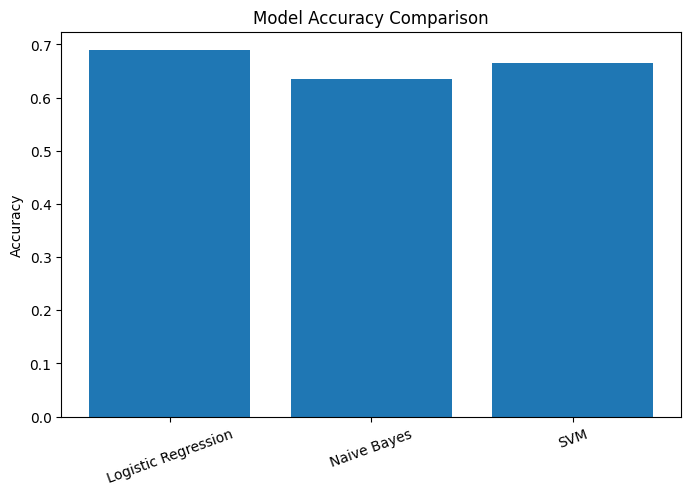

In [40]:
# MODEL COMPARISON DASHBOARD

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.show()




Best Performing Model: Logistic Regression
Accuracy Achieved: 0.6896

Sentiment Distribution:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


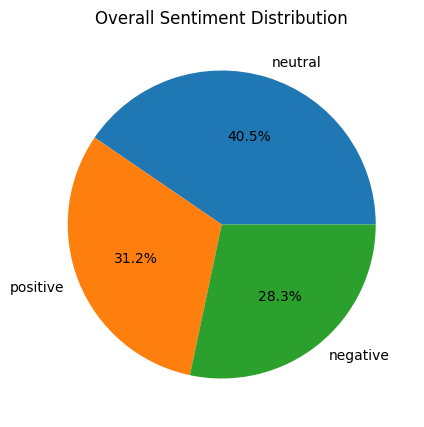

In [41]:

#BUSINESS INSIGHTS DASHBOARD


best_model_name = max(results, key=results.get)

print(f"Best Performing Model: {best_model_name}")
print(f"Accuracy Achieved: {results[best_model_name]:.4f}")

sentiment_distribution = _df['sentiment'].value_counts()

print("\nSentiment Distribution:")
print(sentiment_distribution)

plt.figure(figsize=(8,5))
plt.pie(
    sentiment_distribution.values,
    labels=sentiment_distribution.index,
    autopct='%1.1f%%'
)
plt.title("Overall Sentiment Distribution")
plt.show()

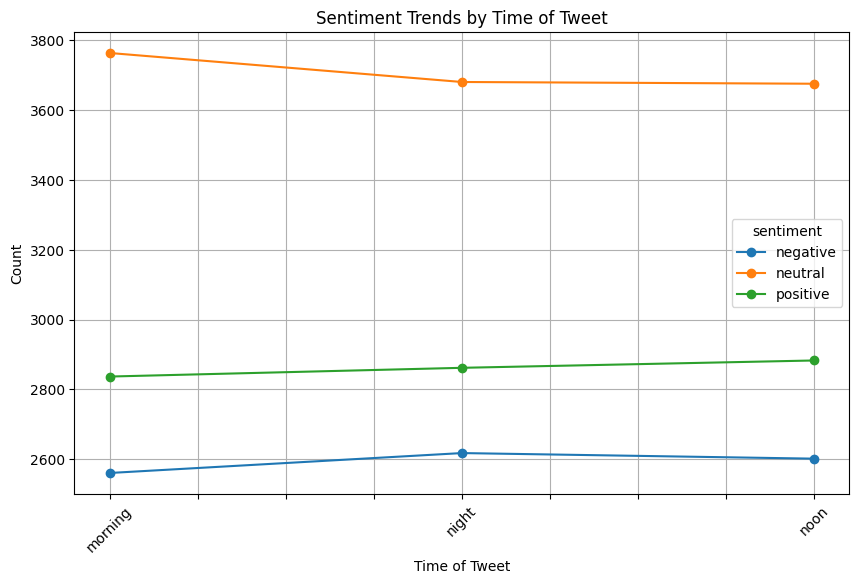

In [42]:
time_sentiment = df.groupby(['Time of Tweet', 'sentiment']).size().unstack(fill_value=0)

time_sentiment.plot(figsize=(10,6), marker='o')
plt.title("Sentiment Trends by Time of Tweet")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

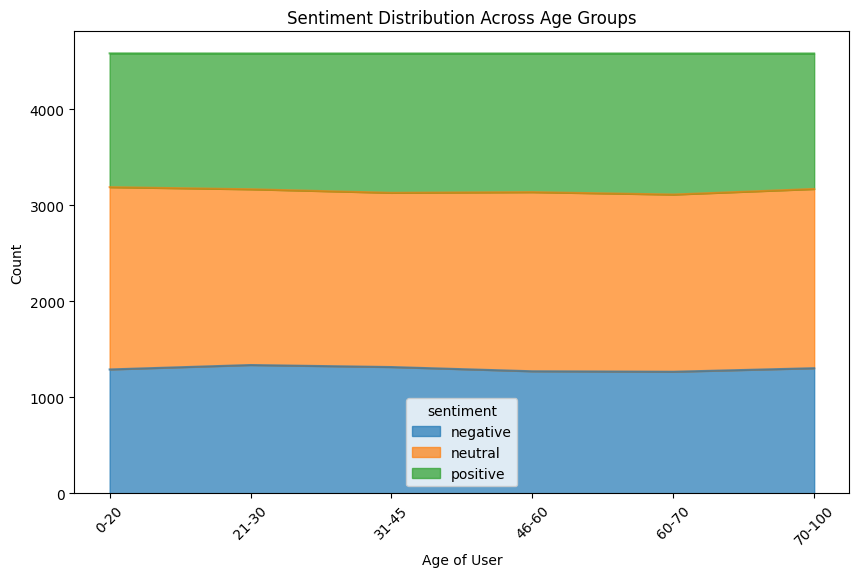

In [43]:
age_sentiment = df.groupby(['Age of User', 'sentiment']).size().unstack(fill_value=0)

age_sentiment.plot.area(figsize=(10,6), alpha=0.7)
plt.title("Sentiment Distribution Across Age Groups")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

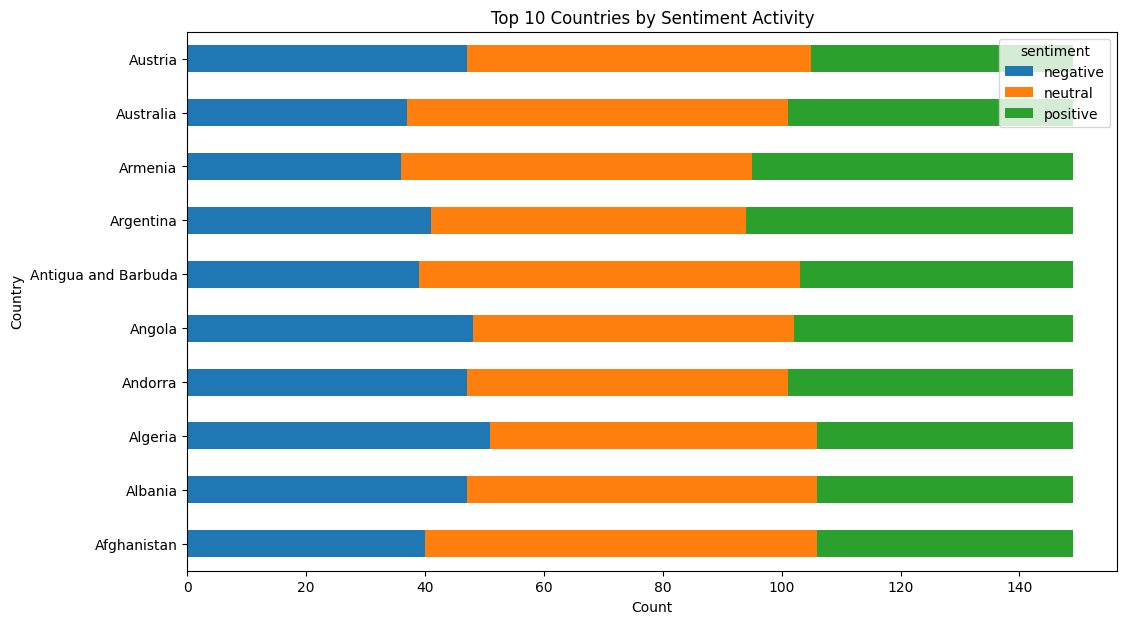

In [44]:
country_sentiment = df.groupby(['Country', 'sentiment']).size().unstack(fill_value=0)

top_countries = country_sentiment.sum(axis=1).sort_values(ascending=False).head(10)

country_sentiment.loc[top_countries.index].plot(
    kind='barh',
    stacked=True,
    figsize=(12,7)
)

plt.title("Top 10 Countries by Sentiment Activity")
plt.xlabel("Count")
plt.show()

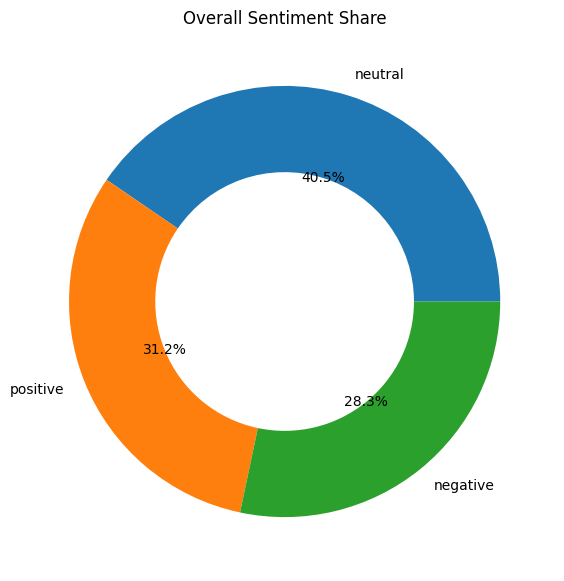

In [45]:
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Overall Sentiment Share")
plt.show()